## Code to run linear and polynomial regression on the algae bloom data

### <b>Load necessary packages</b>

In [153]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score

%matplotlib inline

### <b>Set file info </b>

In [154]:
# Project parameters

data_directory = r"..\data\merged_csvs"

algae_file = "algae_merged"
algae_path = os.path.join(data_directory, algae_file + ".csv")
print(algae_path)

..\data\merged_csvs\algae_merged.csv


### <b>Read in algae bloom data</b>

In [155]:
# Load algae bloom data file

algae_raw_df = pd.read_csv(algae_path)

In [156]:
algae_raw_df.iloc[:5, :]
# vct_raw_df.iloc[:10, 10:25]
# vct_raw_df.iloc[:10, 10:25]

,vct_region,vct_report_date,vct_year,vct_day_of_year,vct_latitude,vct_longitude,vct_water_temp_7days,vct_water_surface_7days,vct_target_bloom_intensity_7days,vct_anabaena_7days,...,noaa_wind_direction_5_min,noaa_air_temp_mean,dec_total nitrogen,dec_total phosphorus,dec_dissolved phosphorus,dec_chlorophyll-a,dec_secchi depth,dec_temperature,vct_target_bloom,vct_target_bloom_intensity
0,Main Lake Central,2014-09-30,2014,273,44.484736,-73.288936,68.240,1.516667,1.550000,0.0,...,211.428571,15.228571,0.340,12.5,5.00,3.830,5.40,NaN,0,1.000
1,Main Lake Central,2014-10-02,2014,275,44.484736,-73.288936,68.240,1.220000,1.550000,1.0,...,233.571429,15.328571,0.340,12.5,5.00,3.830,5.40,NaN,1,3.000
2,Main Lake Central,2015-06-14,2015,165,44.484736,-73.288936,70.175,1.125000,1.821429,1.0,...,254.285714,16.521429,0.400,69.6,13.00,2.300,5.00,12.0,0,1.125
3,Main Lake Central,2015-06-15,2015,166,44.484736,-73.288936,68.090,1.200000,1.696429,1.0,...,250.000000,16.992857,0.400,69.6,13.00,2.300,5.00,12.0,0,1.000
4,Main Lake Central,2015-06-16,2015,167,44.484736,-73.288936,65.690,1.400000,1.553571,1.0,...,252.142857,17.557143,0.405,39.7,9.65,1.815,4.05,14.2,0,1.000


### <b>Clean up and format columns</b>

In [157]:
print(len(algae_raw_df.columns))
algae_raw_df.columns

53


Index(['vct_region', 'vct_report_date', 'vct_year', 'vct_day_of_year',
       'vct_latitude', 'vct_longitude', 'vct_water_temp_7days',
       'vct_water_surface_7days', 'vct_target_bloom_intensity_7days',
       'vct_anabaena_7days', 'vct_aphanizomenon_7days',
       'vct_microcystin_7days', 'vct_oscillatoria_7days',
       'vct_target_bloom_7days', 'vct_water_temp_14days',
       'vct_water_surface_14days', 'vct_target_bloom_intensity_14days',
       'vct_anabaena_14days', 'vct_aphanizomenon_14days',
       'vct_microcystin_14days', 'vct_oscillatoria_14days',
       'vct_target_bloom_14days', 'usgs_water_temp_max_7days',
       'usgs_water_temp_min_7days', 'usgs_water_temp_mean_7days',
       'usgs_conductivity_max_7days', 'usgs_conductivity_min_7days',
       'usgs_conductivity_mean_7days', 'usgs_water_temp_max_14days',
       'usgs_water_temp_min_14days', 'usgs_water_temp_mean_14days',
       'usgs_conductivity_max_14days', 'usgs_conductivity_min_14days',
       'usgs_conductivity_m

In [159]:
# Convert columns to floats, integers, and dates as appropriate

algae_numcols_df = algae_raw_df.copy()

date_cols = ["vct_report_date"]

string_cols = ["vct_region"]

integer_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_target_bloom",
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_day_of_year",
    "vct_year"
]

# Format date columns
algae_numcols_df[date_cols] = (
    algae_numcols_df[date_cols]
    .apply(pd.to_datetime, errors="coerce")
)

# Format string columns
algae_numcols_df[string_cols] = algae_numcols_df[string_cols].astype("string")

# Format integer columns (nullable)
algae_numcols_df[integer_cols] = (
    algae_numcols_df[integer_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype("Int64")
)

# Format all remaining columns as floats
float_cols = algae_numcols_df.columns.difference(string_cols + integer_cols + date_cols)

algae_numcols_df[float_cols] = (
    algae_numcols_df[float_cols]
        .apply(pd.to_numeric, errors="coerce")
        .astype(float)
)

### <b>Define the file structure</b>

In [160]:
# Inspect the data and output the structure to a file

algae_model_df = algae_numcols_df.copy()

summary = pd.DataFrame({
    "dtype": algae_model_df.dtypes,
    "non_null": algae_model_df.notnull().sum(),
    "null": algae_model_df.isnull().sum(),
    "pct_null": (algae_model_df.isnull().mean()*100).round(2)
})

structure_summary = summary.sort_values("pct_null", ascending=False)

structure_summary.to_csv(r"..\data\merged_csvs\dataset_structure_summary_with_nulls.csv")

In [164]:
# Define column types

target_cols = ["vct_target_bloom", "vct_target_bloom_intensity"]

meta_cols = ["vct_report_date", "vct_year"]

exclude_cols = ["vct_region", "vct_latitude", "vct_longitude"]

trailing_7day_cols = [
    "vct_anabaena_7days",
    "vct_aphanizomenon_7days",
    "vct_microcystin_7days",
    "vct_oscillatoria_7days",
    "vct_water_temp_7days",
    "vct_water_surface_7days",
    "usgs_conductivity_mean_7days",
    "usgs_water_temp_mean_7days"
]

trailing_14day_cols = [
    "vct_anabaena_14days",
    "vct_aphanizomenon_14days",
    "vct_microcystin_14days",
    "vct_oscillatoria_14days",
    "vct_water_temp_14days",
    "vct_water_surface_14days",
    "usgs_conductivity_mean_14days",
    "usgs_water_temp_mean_14days"
]

trailing_target_cols = [
    "vct_target_bloom_7days",
    "vct_target_bloom_14days",
    "vct_target_bloom_intensity_7days",
    "vct_target_bloom_intensity_14days"
]

correlated_cols = ["dec_temperature", 
                   "usgs_water_temp_max_7days", "usgs_water_temp_min_7days",
                   "usgs_water_temp_max_14days", "usgs_water_temp_min_14days",
                   "usgs_conductivity_max_7days", "usgs_conductivity_min_7days",
                   "usgs_conductivity_max_14days", "usgs_conductivity_min_14days",
                   "noaa_air_temp_max", "noaa_air_temp_min"]

# Include only 7-day trailing cols in features
# And do not include trailing_target_cols in features yet
other_cols = algae_model_df.columns.difference(meta_cols + correlated_cols + trailing_7day_cols + trailing_14day_cols + trailing_target_cols + target_cols + exclude_cols)
feature_cols = trailing_7day_cols + list(other_cols)

In [165]:
feature_cols

['vct_anabaena_7days',
 'vct_aphanizomenon_7days',
 'vct_microcystin_7days',
 'vct_oscillatoria_7days',
 'vct_water_temp_7days',
 'vct_water_surface_7days',
 'usgs_conductivity_mean_7days',
 'usgs_water_temp_mean_7days',
 'dec_chlorophyll-a',
 'dec_dissolved phosphorus',
 'dec_secchi depth',
 'dec_total nitrogen',
 'dec_total phosphorus',
 'noaa_air_temp_mean',
 'noaa_precipitation',
 'noaa_snow_depth',
 'noaa_snowfall',
 'noaa_wind_direction_2_min',
 'noaa_wind_direction_5_min',
 'noaa_wind_speed_2_min',
 'noaa_wind_speed_5_min',
 'noaa_wind_speed_mean',
 'vct_day_of_year']

### <b>Split the data into training and test sets</b>

In [166]:
# Create train set and test sets

lr_train_set, lr_test_set = train_test_split(algae_model_df, test_size=0.2, random_state=17)

print("Train set:", len(lr_train_set))
print("Test set:", len(lr_test_set))

Train set: 2335
Test set: 584


### <b>Create feature, target, and meta data</b>

##### Create feature, target, and meta data for training data

In [168]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity
# and a dataframe for the meta information aligned with features by index

algae_train_features = lr_train_set[feature_cols].copy()
algae_train_target_bloom = lr_train_set["vct_target_bloom"].copy()
algae_train_target_intensity = lr_train_set["vct_target_bloom_intensity"].copy()
algae_train_meta = lr_train_set[meta_cols].copy()

# Force all feature columns to be numeric

X_train_features_df = algae_train_features.apply(pd.to_numeric, errors="coerce")

In [169]:
# Print out columns that have NaNs

cols_with_nans = X_train_features_df.columns[X_train_features_df.isna().any()]

nan_cols = []

print("Columns with NaNs:")
for col in cols_with_nans:
    nan_cols.append(col)
    print(col, "-", X_train_features_df[col].isna().sum(), "NaNs")

print(nan_cols)

Columns with NaNs:
vct_water_temp_7days - 97 NaNs
usgs_conductivity_mean_7days - 1 NaNs
dec_chlorophyll-a - 203 NaNs
dec_dissolved phosphorus - 196 NaNs
dec_secchi depth - 190 NaNs
dec_total nitrogen - 196 NaNs
dec_total phosphorus - 196 NaNs
['vct_water_temp_7days', 'usgs_conductivity_mean_7days', 'dec_chlorophyll-a', 'dec_dissolved phosphorus', 'dec_secchi depth', 'dec_total nitrogen', 'dec_total phosphorus']


In [170]:
# Fill in NaN columns with means

X_train_features_df[nan_cols] = X_train_features_df[nan_cols].fillna(X_train_features_df[nan_cols].mean())

# Check to make sure there are no more NaNs
nan_counts = X_train_features_df.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [171]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_train_features = X_train_features_df.to_numpy() # converts feature dataframe into an array
y_lr_train_bloom = np.asarray(algae_train_target_bloom) # converts target series into a vector
y_lr_train_intensity = np.asarray(algae_train_target_intensity) # converts target series into a vector

# Find the number of features
n_features = X_train_features_df.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_train_theta = np.zeros((X_train_features_df.shape[1], 1))

# Print shapes
print("X_train_features_df shape:", X_train_features_df.shape)
print("y_lr_train_bloom shape:", y_lr_train_bloom.shape)
print("y_lr_train_intensity shape:", y_lr_train_intensity.shape)
print("lr_train_theta shape:", lr_train_theta.shape)

X_train_features_df shape: (2335, 23)
y_lr_train_bloom shape: (2335,)
y_lr_train_intensity shape: (2335,)
lr_train_theta shape: (23, 1)


##### Create features, targets, and meta data for test data

In [172]:
# Create a dataframe of features 
# and two series of the target data: bloom presence and bloom intensity
# and a dataframe for the meta information aligned with features by index

algae_test_features = lr_test_set[feature_cols].copy()
algae_test_target_bloom = lr_test_set["vct_target_bloom"].copy()
algae_test_target_intensity = lr_test_set["vct_target_bloom_intensity"].copy()
algae_test_meta = lr_test_set[meta_cols].copy()

# Force all feature columns to be numeric

X_test_features_df = algae_test_features.apply(pd.to_numeric, errors="coerce")

In [173]:
# Print out columns that have NaNs

cols_with_nans = X_test_features_df.columns[X_test_features_df.isna().any()]

nan_cols = []

print("Columns with NaNs:")
for col in cols_with_nans:
    nan_cols.append(col)
    print(col, "-", X_test_features_df[col].isna().sum(), "NaNs")

print(nan_cols)

Columns with NaNs:
vct_water_temp_7days - 24 NaNs
usgs_conductivity_mean_7days - 2 NaNs
usgs_water_temp_mean_7days - 2 NaNs
dec_chlorophyll-a - 49 NaNs
dec_dissolved phosphorus - 50 NaNs
dec_secchi depth - 47 NaNs
dec_total nitrogen - 50 NaNs
dec_total phosphorus - 50 NaNs
['vct_water_temp_7days', 'usgs_conductivity_mean_7days', 'usgs_water_temp_mean_7days', 'dec_chlorophyll-a', 'dec_dissolved phosphorus', 'dec_secchi depth', 'dec_total nitrogen', 'dec_total phosphorus']


In [174]:
# Fill in NaN columns with means

X_test_features_df[nan_cols] = X_test_features_df[nan_cols].fillna(X_test_features_df[nan_cols].mean())

# Check to make sure there are no more NaNs
nan_counts = X_test_features_df.isna().sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [175]:
# Convert dataframe into a matrix and targets into vectors 

X_lr_test_features = X_test_features_df.to_numpy() # converts feature dataframe into an array
y_lr_test_bloom = np.asarray(algae_test_target_bloom) # converts target series into a vector
y_lr_test_intensity = np.asarray(algae_test_target_intensity) # converts target series into a vector

# Find the number of features
n_features = X_test_features_df.shape[1]

# Add a bias (intercept) term of all 1s for linear regressoin
# Update: don't need if setting linreg parameter fit_intercept = true
# X_lr_features = np.c_[np.ones(X_lr_features.shape[0]), X_lr_features]

# Initialize parameters (theta) into an all-zero matrix
# lr_theta = np.zeros((n_features, 1))
lr_test_theta = np.zeros((X_test_features_df.shape[1], 1))

# Print shapes
print("X_test_features_df shape:", X_test_features_df.shape)
print("y_lr_test_bloom shape:", y_lr_test_bloom.shape)
print("y_lr_test_intensity shape:", y_lr_test_intensity.shape)
print("lr_test_theta shape:", lr_test_theta.shape)

X_test_features_df shape: (584, 23)
y_lr_test_bloom shape: (584,)
y_lr_test_intensity shape: (584,)
lr_test_theta shape: (23, 1)


### <b>Scale the feature data</b>

##### Scale the training feature data

In [176]:
# Define the scaler
train_scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_lr_train_features_scaled = train_scaler.fit_transform(X_lr_train_features)

# Transform test set using the same scaler:
# X_test_features_scaled = scaler.transform(X_test_features)

# Check the results
print("First 5 rows of scaled features:\n", X_lr_train_features_scaled[:5])
print("Mean of scaled features (should be close to 0):", X_lr_train_features_scaled.mean(axis=0))
print("Std of scaled features (should be 1):", X_lr_train_features_scaled.std(axis=0))

First 5 rows of scaled features:
 [[ 1.05776877  0.96340985 -0.74540565 -0.31600426  0.91146594 -1.45582931
  -0.6210237   1.0061349  -0.59594801 -0.64386567  0.24900264 -0.48701389
  -0.70221866  0.93446035 -0.87114599 -0.05301181 -0.0578836  -0.55051024
  -0.34173159 -0.72504342 -0.73455117 -0.8590533  -0.44084685]
 [ 1.05776877  0.96340985 -0.74540565 -0.31600426  0.0199464   0.17325869
   0.88494054 -0.17368191  0.35191154 -0.48197386 -0.59252553  0.17076962
  -0.43143063  0.34735692 -0.6970285  -0.05301181 -0.0578836  -1.37742656
  -0.08409    -0.07808665 -0.24044959  0.21028187 -0.83193707]
 [-0.9453862   0.96340985 -0.74540565 -0.31600426 -0.43519435 -0.5078978
  -0.2135275  -1.46586223 -0.84579674 -0.59405281  0.81002142 -0.73851935
  -0.54400543  0.38318018 -0.0039726  -0.05301181 -0.0578836  -0.74133709
  -0.50275758  1.45470325  1.68654657  2.13508517 -1.47444243]
 [ 1.05776877  0.96340985 -0.74540565 -0.31600426 -0.04253745 -0.25805015
  -1.32971275 -0.15207354 -0.34218519 

##### Scale the test feature data

In [177]:
# Define the scaler
test_scaler = StandardScaler()

# Fit the scaler on the training features and transform them
X_lr_test_features_scaled = test_scaler.fit_transform(X_lr_test_features)

# Transform test set using the same scaler:
# X_test_features_scaled = scaler.transform(X_test_features)

# Check the results
print("First 5 rows of scaled features:\n", X_lr_test_features_scaled[:5])
print("Mean of scaled features (should be close to 0):", X_lr_test_features_scaled.mean(axis=0))
print("Std of scaled features (should be 1):", X_lr_test_features_scaled.std(axis=0))

First 5 rows of scaled features:
 [[ 1.13586798  1.04555725  1.46280038 -0.32887595 -0.5555752   0.57295656
  -0.42871523 -1.10822139 -0.38140485 -0.51732501  1.60365684 -0.02671572
  -0.56350035 -1.07485236  0.42073713 -0.04141577 -0.04856192 -1.69007826
  -0.72689628 -0.42352845 -0.19652046 -0.35763197  1.31506023]
 [ 1.13586798  1.04555725  1.46280038 -0.32887595 -0.57785367  0.02248887
  -1.12883523 -0.52200109 -0.21178182 -0.52462848  1.07573562  5.57030995
  -0.60208974 -1.319227    0.90374399 -0.04141577 -0.04856192  0.33401308
   0.71039865 -0.44438259 -0.68631335 -0.67691554  0.78313006]
 [-0.880384   -0.95642778 -0.68362028 -0.32887595  0.26878946  0.49702998
  -1.16384123 -0.16938737  0.58867064 -0.26900737 -0.75646154 -0.10134273
   0.65901124  0.32212391 -0.21977195 -0.04141577 -0.04856192 -0.71067922
  -0.55578974  0.348075    0.49364224  0.58501478 -0.81266043]
 [-0.880384   -0.95642778 -0.68362028 -0.32887595  0.34753872  0.44957587
   1.86417777  0.87963844 -0.17393206

### <b>Train the model</b>

##### Train the model on bloom presence (T/F)

In [178]:
# Create the model
lr_bloom_model = LinearRegression(fit_intercept=True) 

# Fit the model
lr_bloom_model.fit(X_lr_train_features_scaled, y_lr_train_bloom)

# Check the R2 score on the training set
lr_bloom_train_r2 = lr_bloom_model.score(X_lr_train_features_scaled, y_lr_train_bloom)
print("Training R2:", lr_bloom_train_r2)

# Get predictions from the model
y_pred_bloom_test = lr_bloom_model.predict(X_lr_test_features_scaled)

# Check the R2 score on the test set
lr_bloom_test_r2 = lr_bloom_model.score(X_lr_test_features_scaled, y_lr_test_bloom)
print("Test R2:", lr_bloom_test_r2)

# Print out coefficients and intercept
print("Coefficients:", lr_bloom_model.coef_)
print("Intercept:", lr_bloom_model.intercept_)

Training R2: 0.14280523208795248
Test R2: 0.13489194696189954
Coefficients: [ 0.004619    0.01569096  0.01294873 -0.01664614  0.02580788  0.00647255
  0.02228905 -0.04573777  0.02947495 -0.04283908 -0.00505488  0.00205881
  0.1247491   0.08831106 -0.00040661  0.01405631 -0.01290318  0.02912653
 -0.01072938 -0.08588246  0.05719868 -0.0115396   0.0621534 ]
Intercept: 0.23768736616702354


##### Train the model on bloom intensity (continuous)

In [179]:
# Create the model
lr_intensity_model = LinearRegression(fit_intercept=True) 

# Fit the model
lr_intensity_model.fit(X_lr_train_features_scaled, y_lr_train_intensity)

# Check the R2 score on the training set
lr_bloom_train_r2 = lr_intensity_model.score(X_lr_train_features_scaled, y_lr_train_intensity)
print("Training R2:", lr_bloom_train_r2)

# Get predictions from the model
y_pred_bloom_test = lr_intensity_model.predict(X_lr_test_features_scaled)

# Check the R2 score on the test set
lr_bloom_test_r2 = lr_intensity_model.score(X_lr_test_features_scaled, y_lr_test_bloom)
print("Test R2:", lr_bloom_test_r2)

# Print out coefficients and intercept
print("Coefficients:", lr_intensity_model.coef_)
print("Intercept:", lr_intensity_model.intercept_)

Training R2: 0.2622045983397142
Test R2: -6.301913881679321
Coefficients: [-0.00656544  0.03482976  0.01250154 -0.00915373  0.02249762  0.00842674
  0.00567452  0.0028481   0.0431376  -0.05937848 -0.01418197 -0.00812456
  0.22746746  0.04483201  0.00630456  0.00895385 -0.01343441  0.04065937
 -0.03470037 -0.04538999  0.00548646 -0.0052788   0.04752805]
Intercept: 1.37891198784789


### <b>Validate the model</b>

##### Validate the bloom presence model (T/F)

In [ ]:
# Set the folds to be the years
groups = algae_train_meta["vct_year"].values

# Define the cross-validation algorithm as Leave One Group Out
logo_bloom = LeaveOneGroupOut()

# Create the model
lr_bloom_model = LinearRegression(fit_intercept=True)

# Do cross-validation one year at a time
cv_r2_scores = cross_val_score(
    lr_bloom_model,
    X_lr_train_features_scaled,
    y_lr_train_bloom,
    cv=logo_bloom.split(X_lr_train_features_scaled, y_lr_train_bloom, groups=groups),
    scoring='r2'
)

print("CV R2 per year:", cv_r2_scores)
print("Mean CV R2:", np.mean(cv_r2_scores))
print("Standard deviation of CV R^2:", np.std(cv_r2_scores))

CV R2 per year: [-1.45011899  0.13255954  0.03639685  0.09226234  0.15167259  0.05581862
  0.02926605  0.00647801  0.09269001]
Mean CV R2: -0.0947749954070918
Standard deviation of CV R^2: 0.48132036875986717


##### Validate the bloom intensity model (continuous)

In [ ]:
# Set the folds to be the years
groups = algae_train_meta["vct_year"].values

# Define the cross-validation algorithm as Leave One Group Out
logo_intensity = LeaveOneGroupOut()

# Create the model
lr_intensity_model = LinearRegression(fit_intercept=True)

# Do cross-validation one year at a time
cv_r2_scores = cross_val_score(
    lr_intensity_model,
    X_lr_train_features_scaled,
    y_lr_train_intensity,
    cv=logo_intensity.split(X_lr_train_features_scaled, y_lr_train_intensity, groups=groups),
    scoring='r2'
)

print("CV R2 per year:", cv_r2_scores)
print("Mean CV R2:", np.mean(cv_r2_scores))
print("Standard deviation of CV R^2:", np.std(cv_r2_scores))

### See whether the model is any good!

In [150]:
# Use mean squared error to measure success

mse_bloom_scorer = make_scorer(mean_squared_error, greater_is_better=False)

cv_bloom_scores = cross_val_score(lr_bloom_model, X_lr_features, y_lr_bloom,
                            scoring=mse_bloom_scorer, cv=lr_bloom_kf)

# Convert negative MSE to positive
cv_bloom_mse = -cv_bloom_scores

print("Cross-validated MSE for each fold:", cv_bloom_mse)
print("Average CV MSE:", np.mean(cv_bloom_mse))
print("Average RMSE:", np.sqrt(np.mean(cv_bloom_mse)))

Cross-validated MSE for each fold: [0.15334718 0.14385227 0.14626655 0.1694588  0.18398749]
Average CV MSE: 0.15938245829141756
Average RMSE: 0.3992273265840122


In [151]:
# Find the standard deviation to compare against

y_lr_bloom.std(), y_lr_bloom.min(), y_lr_bloom.max()

(np.float64(0.42566663262652715), np.int64(0), np.int64(1))

In [152]:
# Convert predictions to binary threshold (50/50)

y_train_binary = (y_train_pred >= 0.5).astype(int)
y_test_binary = (y_test_pred >= 0.5).astype(int)

NameError: name 'y_train_pred' is not defined

In [ ]:
# Find precision, recall, accuracy scores for TRAINING data

# Convert regression predictions to binary using a threshold
y_pred_binary = (y_pred_bloom >= 0.5).astype(int)

# Compute metrics
accuracy = accuracy_score(y_lr_bloom, y_pred_binary)
precision = precision_score(y_lr_bloom, y_pred_binary)
recall = recall_score(y_lr_bloom, y_pred_binary)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.7811563169164882
Precision: 0.6238095238095238
Recall: 0.23268206039076378


PR AUC: 0.4743557674934313


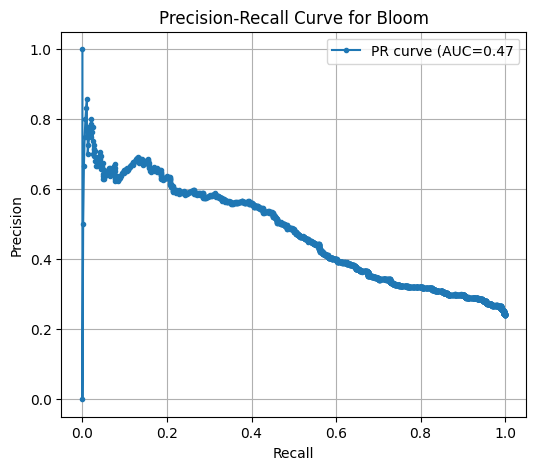

In [ ]:
# Plot PR curve on TEST data

# Get cross-validated predictions
y_scores = cross_val_predict(lr_bloom_model, X_lr_features, y_lr_bloom, cv=lr_bloom_kf)

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_lr_bloom, y_scores)

# Compute PR AUC
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, marker='.', label=f'PR curve (AUC={pr_auc:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Bloom")
plt.legend()
plt.grid(True)
plt.show()

### Feature sweep on logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
import pandas as pd

results = []

for col in X_features_df.columns:

    # Use only one feature column
    X_single = X_features_df[[col]]

    model = LogisticRegression(max_iter=1000)

    scores = cross_validate(
        model,
        X_single,
        y_lr_bloom,
        cv=5,
        scoring=["accuracy", "precision", "recall"]
    )

    results.append({
        "feature": col,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean()
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("accuracy", ascending=False))

c:\Users\hefla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hefla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hefla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

                            feature  accuracy  precision    recall
0                 dec_chlorophyll-a  0.774304   0.621221  0.161741
4              dec_total_phosphorus  0.765310   0.557628  0.165297
2                  dec_secchi_depth  0.759315   0.200000  0.001786
6                         noaa_prcp  0.758887   0.000000  0.000000
5                         noaa_awnd  0.758887   0.000000  0.000000
8                         noaa_snwd  0.758887   0.000000  0.000000
7                         noaa_snow  0.758887   0.000000  0.000000
15    usgs_water_temp_mean_trailing  0.758887   0.000000  0.000000
16            vct_anabaena_trailing  0.758887   0.000000  0.000000
9                         noaa_tavg  0.758887   0.000000  0.000000
10                        noaa_wdf2  0.758887   0.000000  0.000000
11                        noaa_wdf5  0.758887   0.000000  0.000000
12                        noaa_wsf2  0.758887   0.000000  0.000000
13                        noaa_wsf5  0.758887   0.000000  0.00

c:\Users\hefla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hefla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hefla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri